# Glielmo synthetic example: linear encoding and Information Imbalance

This notebook treats $x$ as the **model representation** and $y$ as the
**neural representation**. It:

1. generates a noisy nonlinear relation $y=x(x-1)+\epsilon$;
2. fits the static projections $y\rightarrow\hat{x}$ and
   $x\rightarrow\hat{y}$;
3. computes $R^2$ for both target representations; and
4. computes Information Imbalance between $\hat{x}$ and $\hat{y}$.

By default the projections are in-sample. Set `use_cv=True` to assemble
out-of-fold predictions with the configured cross-validation scheme.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.static_encoding import (
    compute_static_prediction_II,
    fit_static_projection,
)
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.general_utils.utils import get_triu_perms
from useful_stuff.general_utils.II import InformationImbalance

In [2]:
@dataclass
class Cfg:
    # Synthetic relation.
    n_samples: int = 1000
    x_min: float = -.5
    x_max: float = 1.0
    noise_std: float = 0
    y_noise_scale: float = 0.3
    random_seed: int = 0

    # Bidirectional static regression.
    regression_type: str = "lr"
    use_cv: bool = False
    cv_type: str = "kf"
    n_splits: int = 5
    shuffle: bool = True

    # Information Imbalance. Euclidean distance is appropriate for 1D spaces.
    x_RDM_metric: str = "euclidean"
    y_RDM_metric: str = "euclidean"
    k: int = 1
# EOC


cfg = Cfg()
cfg

Cfg(n_samples=1000, x_min=-0.5, x_max=1.0, noise_std=0, y_noise_scale=0.3, random_seed=0, regression_type='lr', use_cv=False, cv_type='kf', n_splits=5, shuffle=True, x_RDM_metric='euclidean', y_RDM_metric='euclidean', k=1)

## Generate $x$ and $y$

The arrays follow the project convention `(features, samples)`. Both spaces
have one feature and share the same observations.

In [40]:
"""
y_func
Generate the noisy nonlinear y representation from x.

INPUT:
    - x: np.ndarray -> one-dimensional x observations
    - rng: np.random.Generator -> seeded random-number generator
    - noise_std: float -> base Gaussian-noise standard deviation
    - noise_scale: float -> multiplier applied to y noise

OUTPUT:
    - y: np.ndarray -> nonlinear y observations
"""
def y_func(x, rng, noise_std, noise_scale):
    noise = rng.normal(0, noise_std, size=len(x)) * noise_scale
    y_1 = x**2 # * (x - 1) + noise
    print()
    
    return y_1[np.newaxis, :] # np.vstack((y_1, y_2)) #  #
# EOF


rng = np.random.default_rng(cfg.random_seed)
latent_u = rng.uniform(cfg.x_min, cfg.x_max, size=cfg.n_samples)
x_values = latent_u + rng.normal(0, cfg.noise_std, size=cfg.n_samples)
y_values = y_func(
    x_values,
    rng=rng,
    noise_std=cfg.noise_std,
    noise_scale=cfg.y_noise_scale,
)

x = x_values[np.newaxis, :]
x_2 = rng.normal(3, 1, size=cfg.n_samples) + rng.normal(-3, 1, size=cfg.n_samples) #np.zeros(noise.shape)
x = np.vstack((x, x_2))
y = y_values # [np.newaxis, :]

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")


x shape: (2, 1000)
y shape: (1, 1000)


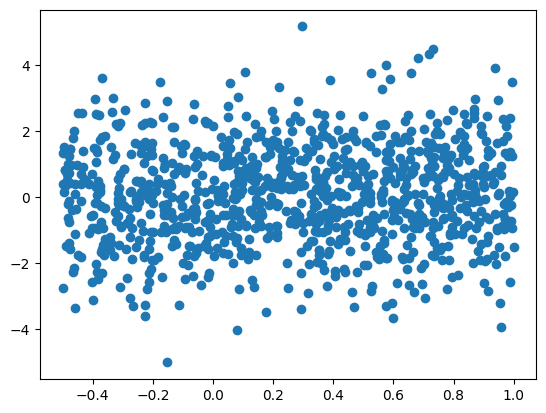

In [ ]:
plt.scatter(x[0,:],x_2)

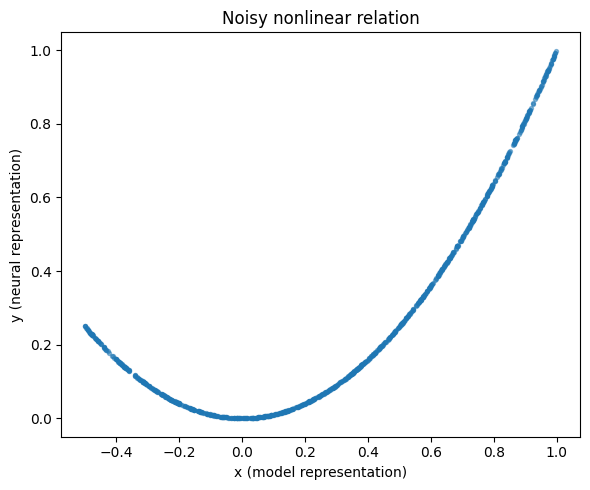

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x[0], y[0], s=8, alpha=0.5)
ax.set_xlabel("x (model representation)")
ax.set_ylabel("y (neural representation)")
ax.set_title("Noisy nonlinear relation")
fig.tight_layout()

## Fit the two static linear projections

`predicted_x` is the $y\rightarrow x$ prediction and `predicted_y` is the
$x\rightarrow y$ prediction. When CV is enabled, both directions use identical
fold assignments and all reported predictions are out of fold.

In [29]:
if cfg.regression_type not in {"lr", "ridge", "lasso", "en"}:
    raise ValueError(f"Unsupported regression_type: {cfg.regression_type}")
# end if cfg.regression_type not in supported types
if cfg.use_cv and cfg.cv_type not in {"loo", "kf"}:
    raise ValueError("Use 'loo' or 'kf' when use_cv=True.")
# end if cfg.use_cv and cfg.cv_type not in supported types

active_cv_type = cfg.cv_type if cfg.use_cv else "same"
y_to_x_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)
x_to_y_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)

# Reset the seed before each direction so CV uses the same folds.
np.random.seed(cfg.random_seed)
predicted_x, x_r2 = fit_static_projection(
    y,
    x,
    y_to_x_encoding,
    use_cv=cfg.use_cv,
)

np.random.seed(cfg.random_seed)
predicted_y, y_r2 = fit_static_projection(
    x,
    y,
    x_to_y_encoding,
    use_cv=cfg.use_cv,
)

Encoding mode: in-sample
y -> x: R²=0.3201, prediction shape=(2, 1000)
x -> y: R²=0.6354, prediction shape=(1, 1000)
y -> x weight shape: (2, 1)
x -> y weight shape: (1, 2)


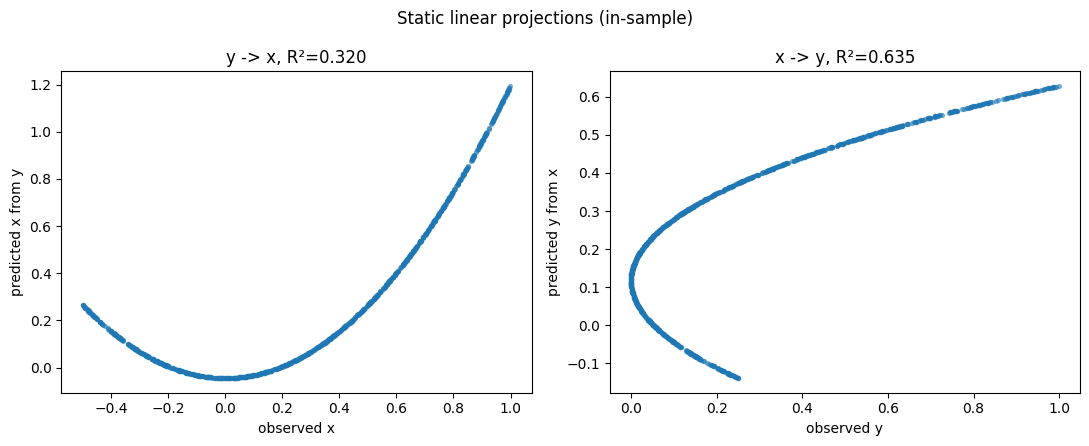

In [30]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(f"y -> x: R²={np.nanmean(x_r2):.4f}, prediction shape={predicted_x.shape}")
print(f"x -> y: R²={np.nanmean(y_r2):.4f}, prediction shape={predicted_y.shape}")
print(f"y -> x weight shape: {y_to_x_encoding.get_weights().shape}")
print(f"x -> y weight shape: {x_to_y_encoding.get_weights().shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x[0], predicted_x[0], s=8, alpha=0.5)
axes[0].set_xlabel("observed x")
axes[0].set_ylabel("predicted x from y")
axes[0].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")

axes[1].scatter(y[0], predicted_y[0], s=8, alpha=0.5)
axes[1].set_xlabel("observed y")
axes[1].set_ylabel("predicted y from x")
axes[1].set_title(f"x -> y, R²={np.nanmean(y_r2):.3f}")

fig.suptitle(f"Static linear projections ({encoding_mode})")
fig.tight_layout()

Encoding mode: in-sample
y -> x: R²=0.3201, prediction shape=(2, 1000)
x -> y: R²=0.6354, prediction shape=(1, 1000)
y -> x weight shape: (2, 1)
x -> y weight shape: (1, 2)


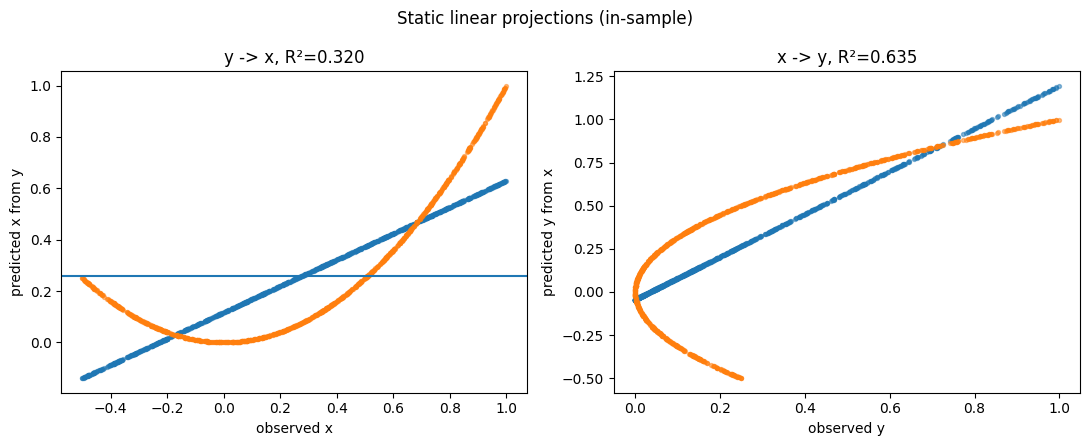

In [31]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(f"y -> x: R²={np.nanmean(x_r2):.4f}, prediction shape={predicted_x.shape}")
print(f"x -> y: R²={np.nanmean(y_r2):.4f}, prediction shape={predicted_y.shape}")
print(f"y -> x weight shape: {y_to_x_encoding.get_weights().shape}")
print(f"x -> y weight shape: {x_to_y_encoding.get_weights().shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x[0], predicted_y[0], s=8, alpha=0.5)
axes[0].scatter(x[0], y[0], s=8, alpha=0.5)
axes[0].axhline(np.mean(y[0]))
axes[0].set_xlabel("observed x")
axes[0].set_ylabel("predicted x from y")
axes[0].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")

axes[1].scatter(y[0], predicted_x[0], s=8, alpha=0.5)
axes[1].scatter(y[0], x[0], s=8, alpha=0.5)
axes[1].set_xlabel("observed y")
axes[1].set_ylabel("predicted y from x")
axes[1].set_title(f"x -> y, R²={np.nanmean(y_r2):.3f}")

fig.suptitle(f"Static linear projections ({encoding_mode})")
fig.tight_layout()

In [32]:
print(np.var(x))
print(np.var(y))

2.51271430859416
0.07520681106812944


## Information Imbalance between the predicted spaces

The helper labels its first input as the neural space and its second input as
the model space. Here those inputs are `predicted_y` and `predicted_x`, so `A2B`
is predicted $y\rightarrow x$ and `B2A` is predicted $x\rightarrow y$.

In [33]:
_, predicted_y_to_x_II, predicted_x_to_y_II = compute_static_prediction_II(
    predicted_neural=predicted_y,
    predicted_model=predicted_x,
    neural_RDM_metric=cfg.y_RDM_metric,
    model_RDM_metric=cfg.x_RDM_metric,
    k=cfg.k,
)

print(f"predicted y -> predicted x: II={predicted_y_to_x_II:.6f}")
print(f"predicted x -> predicted y: II={predicted_x_to_y_II:.6f}")

predicted y -> predicted x: II=0.001718
predicted x -> predicted y: II=0.319118


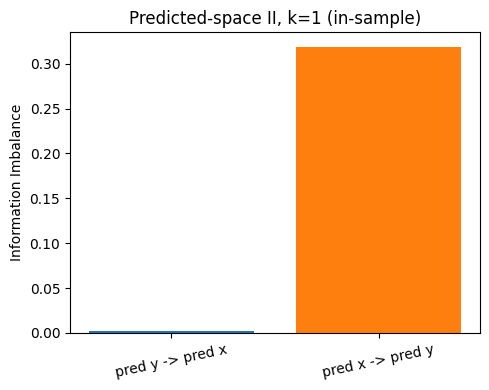

In [34]:
fig, ax = plt.subplots(figsize=(5, 4))
directions = ["pred y -> pred x", "pred x -> pred y"]
ii_values = [predicted_y_to_x_II, predicted_x_to_y_II]
ax.bar(directions, ii_values, color=["tab:blue", "tab:orange"])
ax.set_ylabel("Information Imbalance")
ax.set_title(f"Predicted-space II, k={cfg.k} ({encoding_mode})")
ax.tick_params(axis="x", rotation=12)
fig.tight_layout()

In [35]:
residuals_x = x - predicted_x
residuals_y = y - predicted_y


In [36]:
space_names = ["x", "y", "predicted_x", "predicted_y", "residuals_x", "residuals_y"]
all_spaces = [x, y, predicted_x, predicted_y, residuals_x, residuals_y]
space_metrics = [
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
]

# Rows are source spaces and columns are target spaces.
ii_matrix = np.full((len(all_spaces), len(all_spaces)), np.nan)
space_index_pairs = get_triu_perms(list(range(len(all_spaces))))

for idx_A, idx_B in space_index_pairs:
    ii_obj = InformationImbalance(
        signal_RDM_metric=space_metrics[idx_A],
        model_RDM_metric=space_metrics[idx_B],
        k=cfg.k,
    )
    ii_obj.compute_both_RDMs(all_spaces[idx_A], all_spaces[idx_B])
    ii_obj.compute_both_distance_ranks()
    A_to_B_II, B_to_A_II = ii_obj.compute_both_II()

    # A2B is row A -> column B; B2A occupies the transposed position.
    ii_matrix[idx_A, idx_B] = A_to_B_II
    ii_matrix[idx_B, idx_A] = B_to_A_II
# end for idx_A, idx_B in space_index_pairs

ii_table = pd.DataFrame(ii_matrix, index=space_names, columns=space_names)
ii_table.index.name = "source"
ii_table.columns.name = "target"

# Each cell contains II(row source -> column target); self-pairs are blank.
ii_table.style.format(precision=3, na_rep="--").background_gradient(
    cmap="viridis",
    axis=None,
    vmin=0,
    vmax=1,
).set_caption("Directional Information Imbalance")


target,x,y,predicted_x,predicted_y,residuals_x,residuals_y
source,,,,,,
x,--,0.115,0.115,0.069,0.003,0.135
y,0.910,--,0.000,0.319,1.014,0.412
predicted_x,0.910,0.000,--,0.319,1.014,0.412
predicted_y,0.850,0.002,0.002,--,0.946,0.003
residuals_x,0.172,0.681,0.681,0.556,--,0.553
residuals_y,0.960,0.651,0.651,0.674,0.934,--
